In [2]:
# Install tesseract-ocr system package and pytesseract Python package
!apt-get update -qq > /dev/null
!apt-get install -y tesseract-ocr -qq > /dev/null
!pip install pytesseract -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pytesseract
import os
import re

from google.colab import files

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [6]:
# ============================================================
# UPLOAD GAMBAR
# ============================================================

uploaded = files.upload()

Saving 05_LowResolution_Upsampled0.jpg to 05_LowResolution_Upsampled0 (1).jpg


In [3]:
# ============================================================
# PILIH GAMBAR
# ============================================================

IMAGE_NAME = "05_LowResolution_Upsampled0.jpg"

# Nomor ijazah asli
GROUND_TRUTH = "571012022000056"

In [5]:
# ============================================================
# BACA GAMBAR
# ============================================================

image_path = os.path.join("/content", IMAGE_NAME)

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(
        f"Gambar '{IMAGE_NAME}' tidak ditemukan. "
        "Pastikan nama file sama persis."
    )

print("Nama file :", IMAGE_NAME)
print("Ukuran    :", image.shape)

Nama file : 05_LowResolution_Upsampled0.jpg
Ukuran    : (331, 1079, 3)


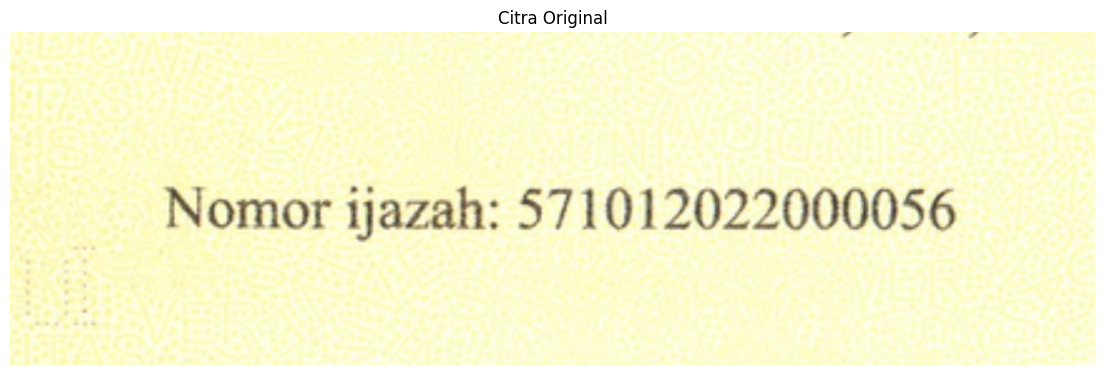

In [7]:
# ============================================================
# ORIGINAL
# ============================================================

plt.figure(figsize=(14, 5))

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.title("Citra Original")
plt.axis("off")

plt.show()

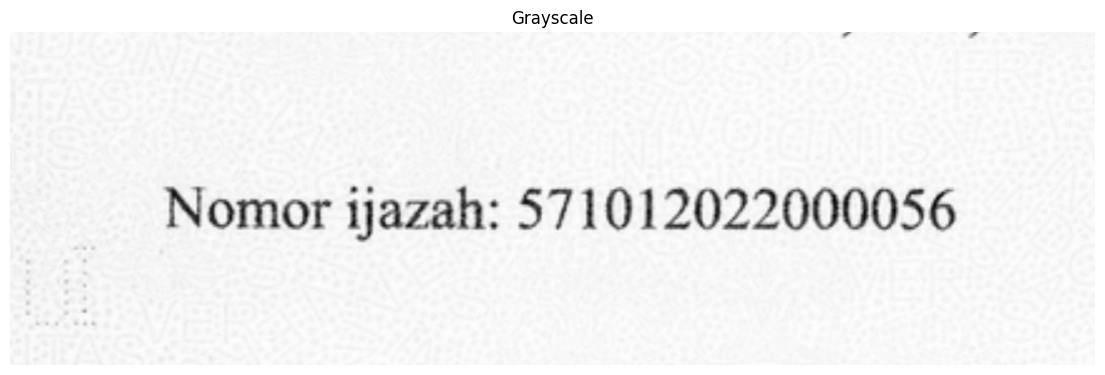

In [8]:
# ============================================================
# GRAYSCALE
# ============================================================

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(14, 5))

plt.imshow(
    gray,
    cmap="gray"
)

plt.title("Grayscale")
plt.axis("off")

plt.show()

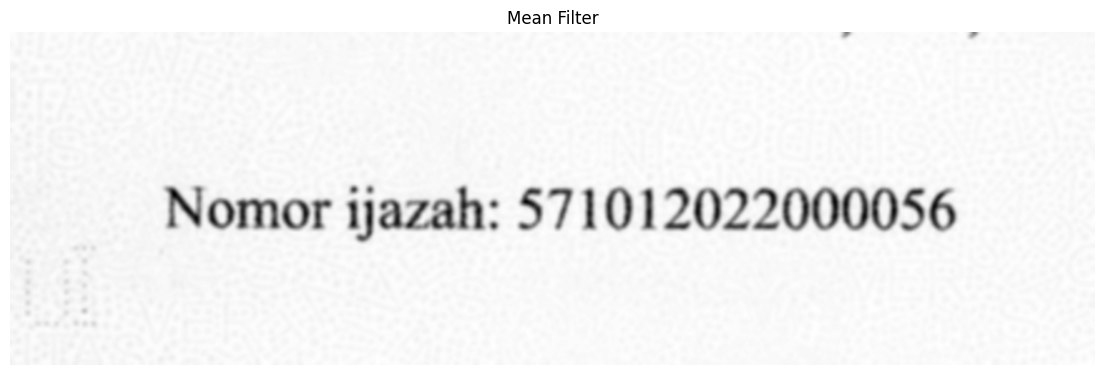

In [9]:
# ============================================================
# MEAN FILTER
# ============================================================

mean_filter = cv2.blur(
    gray,
    (5, 5)
)

plt.figure(figsize=(14, 5))

plt.imshow(
    mean_filter,
    cmap="gray"
)

plt.title("Mean Filter")
plt.axis("off")

plt.show()

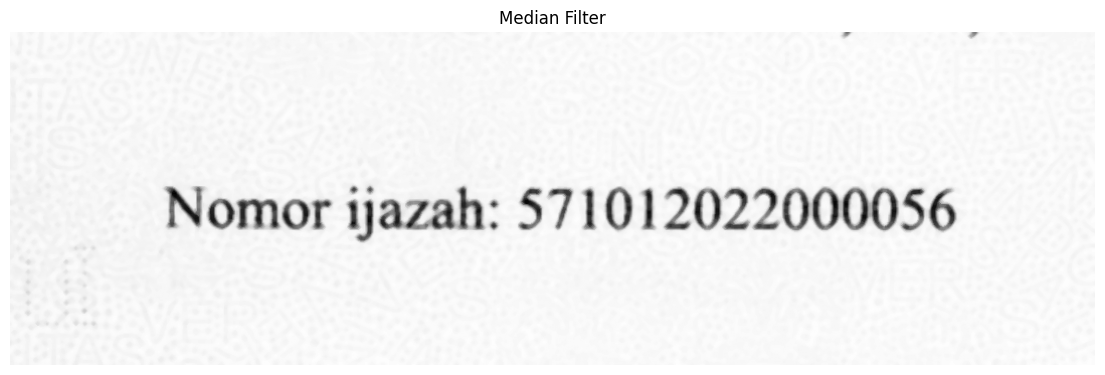

In [10]:
# ============================================================
# MEDIAN FILTER
# ============================================================

median_filter = cv2.medianBlur(
    gray,
    5
)

plt.figure(figsize=(14, 5))

plt.imshow(
    median_filter,
    cmap="gray"
)

plt.title("Median Filter")
plt.axis("off")

plt.show()

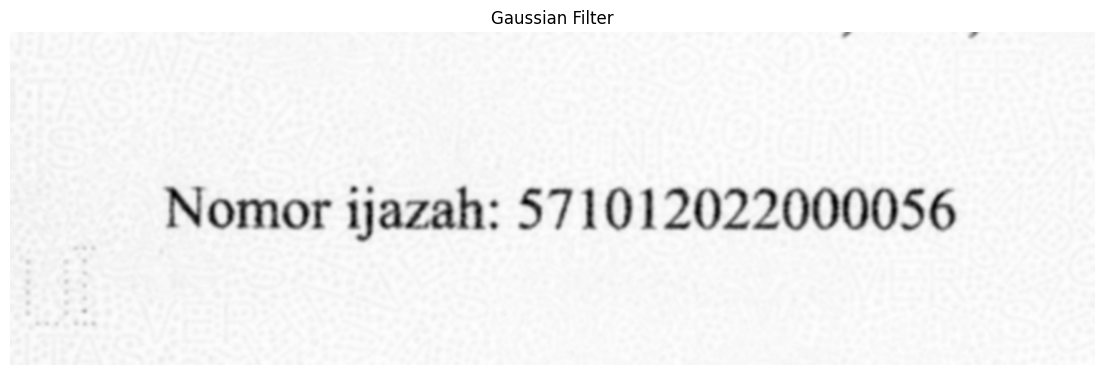

In [11]:
# ============================================================
# GAUSSIAN FILTER
# ============================================================

gaussian_filter = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

plt.figure(figsize=(14, 5))

plt.imshow(
    gaussian_filter,
    cmap="gray"
)

plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

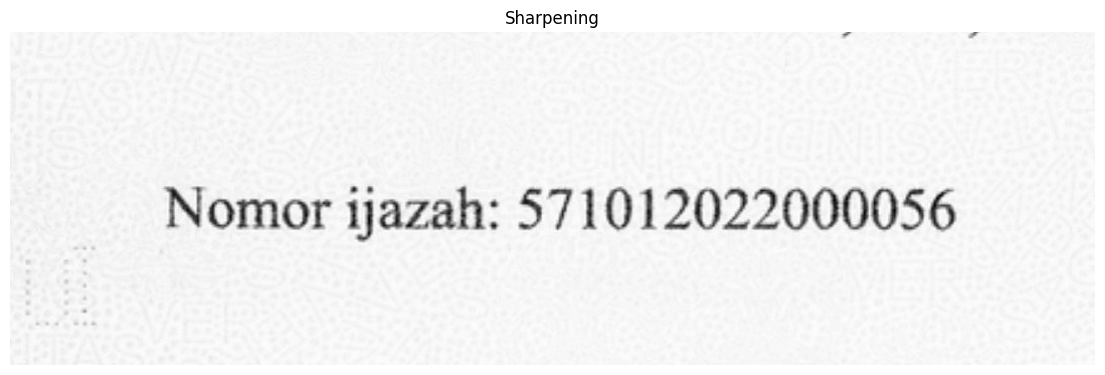

In [12]:
# ============================================================
# SHARPENING
# ============================================================

blur_for_sharpen = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

sharpening = cv2.addWeighted(
    gray,
    1.5,
    blur_for_sharpen,
    -0.5,
    0
)

plt.figure(figsize=(14, 5))

plt.imshow(
    sharpening,
    cmap="gray"
)

plt.title("Sharpening")
plt.axis("off")

plt.show()

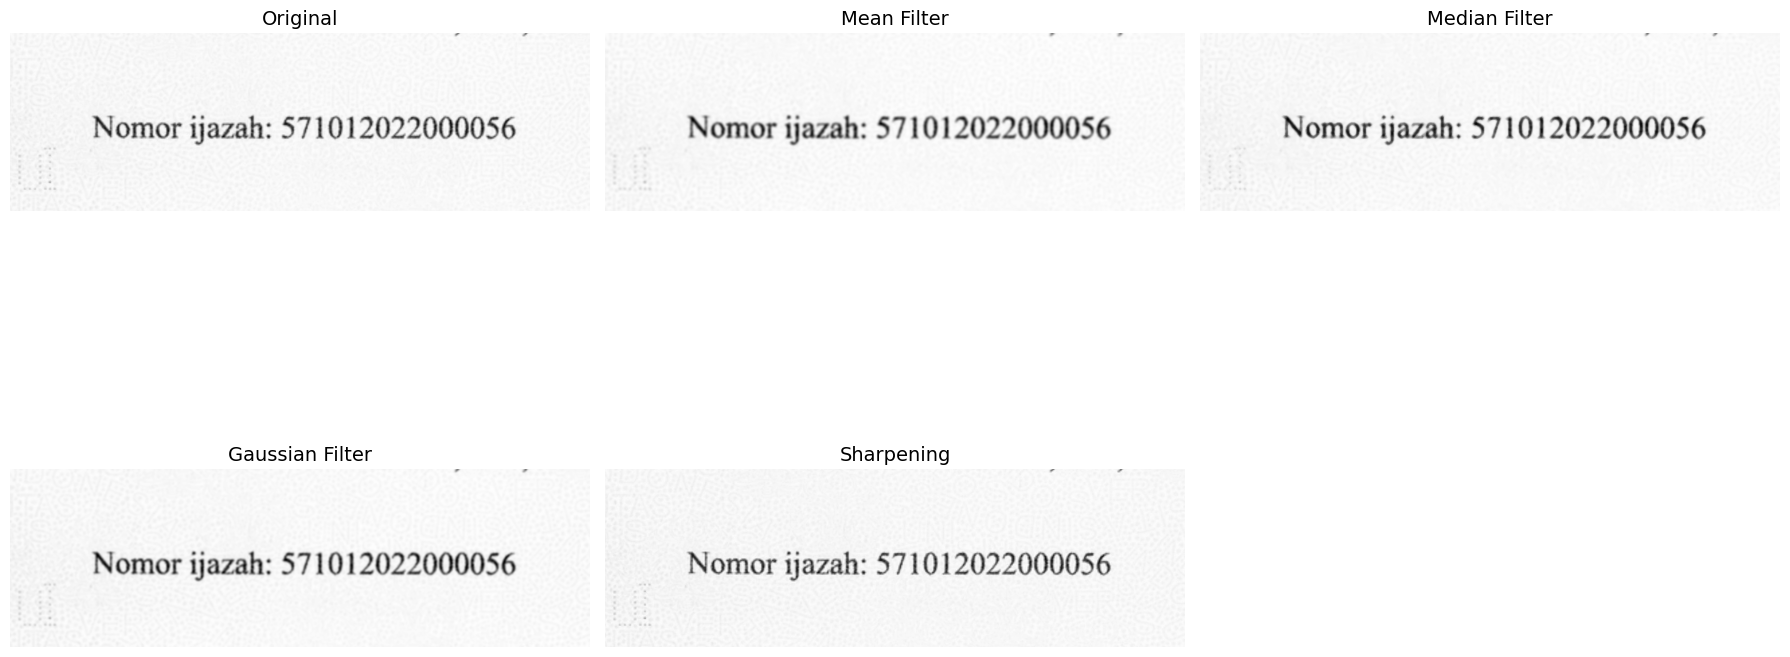

In [13]:
# ============================================================
# PERBANDINGAN SEMUA METODE
# ============================================================

images = [
    ("Original", gray),
    ("Mean Filter", mean_filter),
    ("Median Filter", median_filter),
    ("Gaussian Filter", gaussian_filter),
    ("Sharpening", sharpening)
]

plt.figure(figsize=(18, 10))

for i, (title, img) in enumerate(images):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        img,
        cmap="gray"
    )

    plt.title(title, fontsize=14)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# FUNGSI OCR
# ============================================================

def run_ocr(img):

    # Threshold Otsu
    _, thresh = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # OCR hanya karakter angka
    config = (
        "--psm 7 "
        "-c tessedit_char_whitelist=0123456789"
    )

    text = pytesseract.image_to_string(
        thresh,
        config=config
    )

    # Ambil ANGKA SAJA dari hasil OCR
    digits = re.sub(
        r"[^0-9]",
        "",
        text
    )

    return digits

In [15]:
# ============================================================
# FUNGSI AKURASI OCR
# ============================================================

def calculate_accuracy(predicted, ground_truth):

    # Ambil angka saja
    predicted = re.sub(
        r"[^0-9]",
        "",
        str(predicted)
    )

    ground_truth = re.sub(
        r"[^0-9]",
        "",
        str(ground_truth)
    )

    # Hitung karakter yang benar berdasarkan posisi
    correct = 0

    for i in range(
        min(
            len(predicted),
            len(ground_truth)
        )
    ):

        if predicted[i] == ground_truth[i]:
            correct += 1

    # Akurasi berdasarkan jumlah karakter ground truth
    if len(ground_truth) > 0:
        accuracy = (
            correct / len(ground_truth)
        ) * 100
    else:
        accuracy = 0

    return correct, accuracy

In [16]:
print("GROUND TRUTH :", GROUND_TRUTH)

GROUND TRUTH : 571012022000056


In [17]:
# ============================================================
# OCR SEMUA METODE
# ============================================================

processed_images = {

    "Original": gray,

    "Mean Filter": mean_filter,

    "Median Filter": median_filter,

    "Gaussian Filter": gaussian_filter,

    "Sharpening": sharpening

}

results = []

for method, img in processed_images.items():

    ocr_result = run_ocr(img)

    correct, accuracy = calculate_accuracy(
        ocr_result,
        GROUND_TRUTH
    )

    results.append({

        "Metode": method,

        "Hasil OCR": ocr_result,

        "Karakter Benar":
            f"{correct}/{len(GROUND_TRUTH)}",

        "Akurasi":
            f"{accuracy:.2f}%"

    })

print("OCR selesai.")

OCR selesai.


In [18]:
# ============================================================
# HASIL OCR
# ============================================================

df_results = pd.DataFrame(results)

print("============================================================")
print("HASIL OCR")
print("============================================================")

display(df_results)

HASIL OCR


,Metode,Hasil OCR,Karakter Benar,Akurasi
0,Original,571,3/15,20.00%
1,Mean Filter,,0/15,0.00%
2,Median Filter,,0/15,0.00%
3,Gaussian Filter,,0/15,0.00%
4,Sharpening,,0/15,0.00%
